<a href="https://colab.research.google.com/github/Priyall33/Pcos-Endometrosis-risk-model/blob/main/05_Model2_BRFSS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 05 — Model 2: Lifestyle Risk Model (BRFSS)


This notebook trains the second XGBoost model using CDC BRFSS lifestyle and metabolic data. This is the **consumer-facing model** in our two-model architecture.


In [1]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

drive.mount('/content/drive')
os.makedirs('outputs', exist_ok=True)

!pip install imbalanced-learn -q

# Load BRFSS splits
save_dir = '/content/drive/MyDrive/model_data/'

X_train = pd.read_csv(f'{save_dir}brfss_X_train.csv')
X_test  = pd.read_csv(f'{save_dir}brfss_X_test.csv')
y_train = pd.read_csv(f'{save_dir}brfss_y_train.csv').squeeze()
y_test  = pd.read_csv(f'{save_dir}brfss_y_test.csv').squeeze()

print(" DATA LOADED ")
print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_test  : {y_test.shape}")
print(f"\nTraining label distribution:")
print(y_train.value_counts())
print(f"High risk rate: {y_train.mean()*100:.1f}%")
print(f"\nFeatures:")
for col in X_train.columns:
    missing = X_train[col].isna().mean() * 100
    print(f"  {col:<25} — {missing:.1f}% missing")

Mounted at /content/drive
 DATA LOADED 
X_train : (183632, 13)
X_test  : (45909, 13)
y_train : (183632,)
y_test  : (45909,)

Training label distribution:
high_risk
0    167568
1     16064
Name: count, dtype: int64
High risk rate: 8.7%

Features:
  BMI                       — 12.3% missing
  insulin_resistance        — 0.0% missing
  takes_insulin             — 0.0% missing
  prediabetes               — 0.0% missing
  has_diabetes              — 0.0% missing
  BPHIGH6                   — 0.4% missing
  GENHLTH                   — 0.2% missing
  PHYSHLTH                  — 5.1% missing
  MENTHLTH                  — 4.0% missing
  ADDEPEV3                  — 0.5% missing
  EXERANY2                  — 0.3% missing
  _AGE80                    — 1.6% missing
  _RACE                     — 4.1% missing


SMOTE - applying to training set

In [2]:
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer

print(" BEFORE SMOTE ")
print(f"Low risk  (0): {(y_train==0).sum():,}")
print(f"High risk (1): {(y_train==1).sum():,}")
print(f"Imbalance ratio: {(y_train==0).sum()/(y_train==1).sum():.1f}:1")

# temporarily fill NaN with median for SMOTE only
imputer = SimpleImputer(strategy='median')
X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns
)

# apply SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train_imputed, y_train
)

print(f"\nAFTER SMOTE ")
print(f"Low risk  (0): {(y_train_balanced==0).sum():,}")
print(f"High risk (1): {(y_train_balanced==1).sum():,}")
print(f"Total         : {len(y_train_balanced):,}")
print(f"High risk rate: {y_train_balanced.mean()*100:.1f}%")


 BEFORE SMOTE 
Low risk  (0): 167,568
High risk (1): 16,064
Imbalance ratio: 10.4:1

AFTER SMOTE 
Low risk  (0): 167,568
High risk (1): 167,568
Total         : 335,136
High risk rate: 50.0%


XGBoost Model 2

In [3]:
from xgboost import XGBClassifier
import time

# Calculate class weight ratio from original training data
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos = neg_count / pos_count
print(f"scale_pos_weight: {scale_pos:.2f}")
print(f"Training on {len(X_train_balanced):,} rows after SMOTE...")

start = time.time()

model2 = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    random_state=42,
    eval_metric='auc',
    verbosity=0
)

model2.fit(
    X_train_balanced,
    y_train_balanced,
    eval_set=[(X_test, y_test)],
    verbose=False
)

end = time.time()

scale_pos_weight: 10.43
Training on 335,136 rows after SMOTE...


Find the Optimal threshold

In [4]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

# Get probability scores
y_prob = model2.predict_proba(X_test)[:, 1]

print("THRESHOLD ANALYSIS ")
print(f"{'Threshold':<12} {'Recall':<10} {'Precision':<12} {'F1':<10} {'Flagged'}")
print("-" * 55)

for thresh in [0.1, 0.2, 0.25, 0.3, 0.35, 0.4, 0.5]:
    y_pred_t = (y_prob >= thresh).astype(int)
    r = recall_score(y_test, y_pred_t, zero_division=0)
    p = precision_score(y_test, y_pred_t, zero_division=0)
    f = f1_score(y_test, y_pred_t, zero_division=0)
    flagged = y_pred_t.sum()
    print(f"  {thresh:<10} {r*100:<10.1f} {p*100:<12.1f} {f*100:<10.1f} {flagged:,}")

print(f"\nTotal actual high risk cases in test set: {y_test.sum():,}")

THRESHOLD ANALYSIS 
Threshold    Recall     Precision    F1         Flagged
-------------------------------------------------------
  0.1        99.4       38.6         55.6       10,346
  0.2        98.8       44.2         61.1       8,966
  0.25       98.2       47.5         64.0       8,297
  0.3        97.8       51.1         67.1       7,683
  0.35       97.3       54.8         70.1       7,128
  0.4        96.9       57.6         72.2       6,755
  0.5        95.9       63.0         76.0       6,116

Total actual high risk cases in test set: 4,016


Final model 2 evaulation

In [5]:
# Set final threshold
final_threshold = 0.3
y_pred_final = (y_prob >= final_threshold).astype(int)

accuracy  = accuracy_score(y_test, y_pred_final)
precision = precision_score(y_test, y_pred_final, zero_division=0)
recall    = recall_score(y_test, y_pred_final, zero_division=0)
f1        = f1_score(y_test, y_pred_final, zero_division=0)
auc_roc   = roc_auc_score(y_test, y_prob)

print(" FINAL MODEL 2 PERFORMANCE (BRFSS Lifestyle Model) ")
print(f"Classification threshold : {final_threshold}")
print(f"Accuracy                 : {accuracy*100:.1f}%")
print(f"Precision                : {precision*100:.1f}%")
print(f"Recall                   : {recall*100:.1f}%")
print(f"F1 Score                 : {f1*100:.1f}%")
print(f"AUC-ROC                  : {auc_roc:.3f}")

cm = confusion_matrix(y_test, y_pred_final)
print(f"\nConfusion Matrix:")
print(f"  True Negative  (correctly low risk)  : {cm[0,0]:,}")
print(f"  False Positive (wrongly flagged)      : {cm[0,1]:,}")
print(f"  False Negative (missed high risk)     : {cm[1,0]:,}")
print(f"  True Positive  (correctly caught)     : {cm[1,1]:,}")

print(f"  Out of {y_test.sum():,} high risk women in test set")
print(f"  Model caught {cm[1,1]:,} ({recall*100:.1f}%)")
print(f"  Model missed {cm[1,0]:,} ({(1-recall)*100:.1f}%)")

print(f"\n{classification_report(y_test, y_pred_final, target_names=['Low Risk', 'High Risk'])}")

 FINAL MODEL 2 PERFORMANCE (BRFSS Lifestyle Model) 
Classification threshold : 0.3
Accuracy                 : 91.6%
Precision                : 51.1%
Recall                   : 97.8%
F1 Score                 : 67.1%
AUC-ROC                  : 0.989

Confusion Matrix:
  True Negative  (correctly low risk)  : 38,136
  False Positive (wrongly flagged)      : 3,757
  False Negative (missed high risk)     : 90
  True Positive  (correctly caught)     : 3,926
  Out of 4,016 high risk women in test set
  Model caught 3,926 (97.8%)
  Model missed 90 (2.2%)

              precision    recall  f1-score   support

    Low Risk       1.00      0.91      0.95     41893
   High Risk       0.51      0.98      0.67      4016

    accuracy                           0.92     45909
   macro avg       0.75      0.94      0.81     45909
weighted avg       0.96      0.92      0.93     45909



Model Visualization

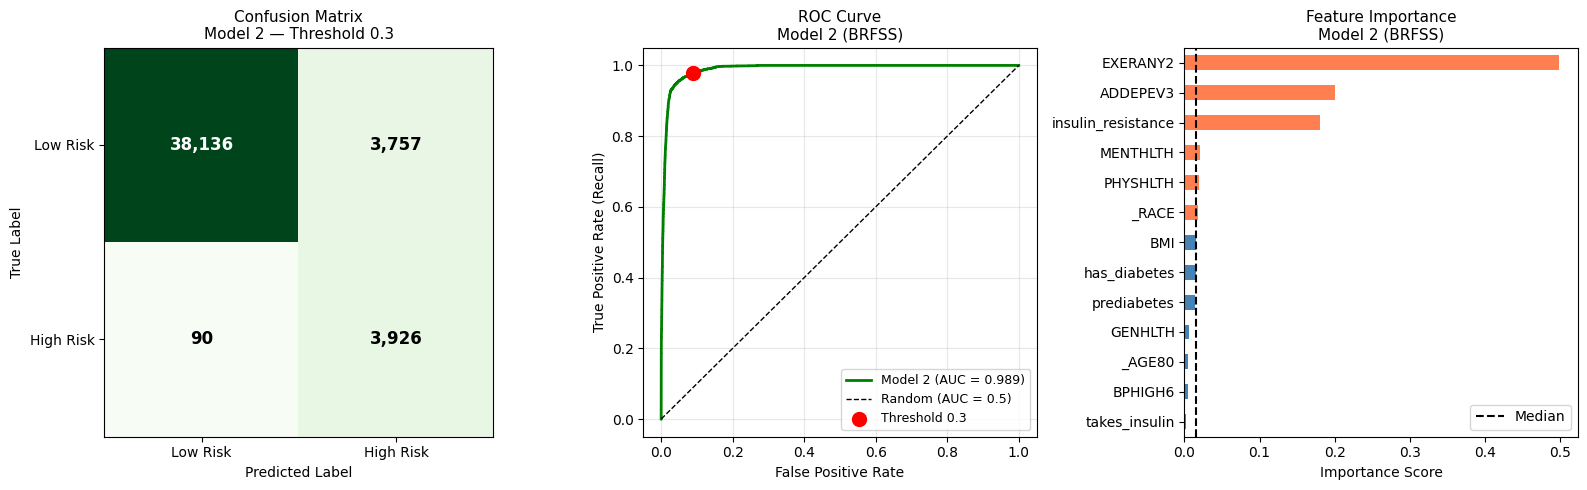

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
axes[0].imshow(cm, cmap='Greens')
axes[0].set_title(f'Confusion Matrix\nModel 2 — Threshold {final_threshold}',
                  fontsize=11)
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].set_xticks([0,1])
axes[0].set_yticks([0,1])
axes[0].set_xticklabels(['Low Risk', 'High Risk'])
axes[0].set_yticklabels(['Low Risk', 'High Risk'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, f'{cm[i,j]:,}',
                    ha='center', va='center',
                    fontsize=12, fontweight='bold',
                    color='white' if cm[i,j] > cm.max()/2 else 'black')

# ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='green', linewidth=2,
             label=f'Model 2 (AUC = {auc_roc:.3f})')
axes[1].plot([0,1], [0,1], 'k--', linewidth=1,
             label='Random (AUC = 0.5)')

# threshold
idx = np.argmin(np.abs(thresholds_roc - final_threshold))
axes[1].scatter(fpr[idx], tpr[idx], color='red',
                s=100, zorder=5, label=f'Threshold {final_threshold}')
axes[1].set_title('ROC Curve\nModel 2 (BRFSS)', fontsize=11)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# Feature Importance
importance = pd.Series(
    model2.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

colors = ['coral' if v > importance.median()
          else 'steelblue' for v in importance.values]
importance.plot(kind='barh', ax=axes[2], color=colors)
axes[2].set_title('Feature Importance\nModel 2 (BRFSS)', fontsize=11)
axes[2].set_xlabel('Importance Score')
axes[2].axvline(x=importance.median(), color='black',
                linestyle='--', label='Median')
axes[2].legend()

plt.tight_layout()
plt.savefig('outputs/model2_final_performance.png',
            dpi=150, bbox_inches='tight')
plt.show()


In [7]:
import pickle
import json

# Save model
model_path = '/content/drive/MyDrive/model_data/model2_brfss.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(model2, f)

# Save config
model_config = {
    'threshold'    : final_threshold,
    'auc_roc'      : round(auc_roc, 3),
    'recall'       : round(recall, 3),
    'precision'    : round(precision, 3),
    'f1'           : round(f1, 3),
    'features'     : list(X_train.columns),
    'training_rows': len(X_train_balanced),
    'algorithm'    : 'XGBoost',
    'dataset'      : 'CDC BRFSS 2023',
    'smote'        : True,
    'label_type'   : 'proxy — 5+ risk factors',
    'notes'        : f'Threshold {final_threshold} optimized for recall'
}

config_path = '/content/drive/MyDrive/model_data/model2_config.json'
with open(config_path, 'w') as f:
    json.dump(model_config, f, indent=2)


print(f"\nFinal Model 2 Summary:")
print(f"  Algorithm      : XGBoost")
print(f"  Dataset        : CDC BRFSS 2023")
print(f"  Training rows  : {len(X_train_balanced):,} (after SMOTE)")
print(f"  Features       : {len(X_train.columns)}")
print(f"  Threshold      : {final_threshold}")
print(f"  AUC-ROC        : {auc_roc:.3f}")
print(f"  Recall         : {recall*100:.1f}%")
print(f"  Precision      : {precision*100:.1f}%")
print(f"  F1 Score       : {f1*100:.1f}%")



Final Model 2 Summary:
  Algorithm      : XGBoost
  Dataset        : CDC BRFSS 2023
  Training rows  : 335,136 (after SMOTE)
  Features       : 13
  Threshold      : 0.3
  AUC-ROC        : 0.989
  Recall         : 97.8%
  Precision      : 51.1%
  F1 Score       : 67.1%
